In [1]:
!pip install osmnx geopandas shapely scikit-learn matplotlib contextily mapclassify

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

from shapely.geometry import box
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.neighbors import BallTree

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.6 MB/s eta 0:00:00


In [2]:
# Центральная часть Санкт-Петербурга
bbox = (30.18, 59.86, 30.55, 60.03)
polygon_wgs = box(*bbox)

print(f"Bbox: {bbox}")
print(f"Polygon: {polygon_wgs}")

Bbox: (30.18, 59.86, 30.55, 60.03)
Polygon: POLYGON ((30.55 59.86, 30.55 60.03, 30.18 60.03, 30.18 59.86, 30.55 59.86))


In [3]:
# Загрузка графа дорожной сети
G = ox.graph_from_polygon(
    polygon_wgs,           # область
    network_type="drive",  # только автомобильные дороги
    simplify=True,
    retain_all=False
)

# Получаем GeoDataFrame узлов и рёбер
nodes, edges = ox.graph_to_gdfs(G, nodes=True, edges=True)

print(f"Узлов: {len(nodes)}")
print(f"Рёбер (сегментов дорог): {len(edges)}")
edges.head()

Узлов: 8017
Рёбер (сегментов дорог): 16176


osmid       highway lanes  maxspeed  \
u      v          key                                                          
219808 2327840    0                   33997807  primary_link     2  RU:urban   
       389449562  0                  201380605       primary     3  RU:urban   
219811 1832085962 0                   33997784  primary_link     2  RU:urban   
       1465050831 0    [1123339577, 178581714]       primary     3  RU:urban   
219812 249890545  0                    4459876       primary     2  RU:urban   

                       oneway reversed      length                       name  \
u      v          key                                                           
219808 2327840    0     False    False   26.026139                        NaN   
       389449562  0      True    False   31.504625         Лиговский проспект   
219811 1832085962 0     False    False   27.905147                        NaN   
       1465050831 0      True    False  394.654005         Лиговский проспект   
219812 249890545  0      True    False   33.758153  Воздухоплавательная улица   

                                                                geometry  \
u      v          key                                                      
219808 2327840    0    LINESTRING (30.33142 59.89509, 30.33109 59.89526)   
       389449562  0    LINESTRING (30.33142 59.89509, 30.33182 59.89529)   
219811 1832085962 0      LINESTRING (30.33748 59.8993, 30.33793 59.8992)   
       1465050831 0    LINESTRING (30.33748 59.8993, 30.3372 59.89897...   
219812 249890545  0    LINESTRING (30.33955 59.90173, 30.33982 59.90146)   

                      bridge junction  ref width tunnel access  
u      v          key                                           
219808 2327840    0      NaN      NaN  NaN   NaN    NaN    NaN  
       389449562  0      NaN      NaN  NaN   NaN    NaN    NaN  
219811 1832085962 0      NaN      NaN  NaN   NaN    NaN    NaN  
       1465050831 0      NaN      NaN  NaN   NaN    NaN    NaN  
219812 249890545  0      NaN      NaN  NaN   NaN    NaN    NaN

In [4]:
# Копируем рёбра и переводим в метрическую CRS
edges_m = edges.copy()
edges_m = edges_m.to_crs("EPSG:32636")

print(f"Исходная CRS: {edges.crs}")
print(f"Новая CRS: {edges_m.crs}")

# Проверим, что геометрия изменилась (координаты стали большими — метры)
print(f"\nПример геометрии в градусах: {edges.iloc[0].geometry}")
print(f"Пример геометрии в метрах: {edges_m.iloc[0].geometry}")

Исходная CRS: epsg:4326
Новая CRS: EPSG:32636

Пример геометрии в градусах: LINESTRING (30.3314172 59.8950924, 30.3310927 59.8952606)
Пример геометрии в метрах: LINESTRING (350708.4507397586 6642736.477840697, 350691.0583836738 6642755.931278272)


In [5]:
roads = edges_m.copy()

# Длина сегмента в метрах
roads["length_m_geom"] = roads.geometry.length

# Центроид сегмента
roads["centroid_x"] = roads.geometry.centroid.x
roads["centroid_y"] = roads.geometry.centroid.y

# Функция для прямого расстояния между началом и концом LineString
def straight_distance(geom):
    coords = list(geom.coords)
    x1, y1 = coords[0]
    x2, y2 = coords[-1]
    return ((x2 - x1)**2 + (y2 - y1)**2)**0.5

roads["straight_dist_m"] = roads.geometry.apply(straight_distance)

# Извилистость: отношение длины линии к прямому расстоянию
roads["sinuosity"] = roads["length_m_geom"] / roads["straight_dist_m"].replace(0, np.nan)
roads["sinuosity"] = roads["sinuosity"].replace([np.inf, -np.inf], np.nan).fillna(1)

# Направление дороги в радианах
def segment_angle(geom):
    coords = list(geom.coords)
    x1, y1 = coords[0]
    x2, y2 = coords[-1]
    dx = x2 - x1
    dy = y2 - y1
    return np.arctan2(dy, dx)

roads["angle_rad"] = roads.geometry.apply(segment_angle)

# Посмотрим статистику
roads[["length_m_geom", "straight_dist_m", "sinuosity", "angle_rad"]].describe()

,length_m_geom,straight_dist_m,sinuosity,angle_rad
count,16176.000000,16176.000000,16176.000000,16176.000000
mean,183.554633,177.120246,1.045379,0.001167
std,243.995907,228.388397,0.896788,1.818570
min,1.236514,0.000000,1.000000,-3.141433
25%,28.296945,27.432919,1.000000,-1.582503
50%,106.825070,104.682539,1.000018,-0.000176
75%,248.837794,243.176946,1.002707,1.554398
max,6640.370574,5357.940848,76.797540,3.140873


In [6]:
# Приводим highway к строке
roads["highway_str"] = roads["highway"].apply(lambda x: ",".join(x) if isinstance(x, list) else str(x))

# One-hot encoding
highway_dummies = pd.get_dummies(roads["highway_str"], prefix="highway")

# Добавляем к основному DataFrame
roads = pd.concat([roads, highway_dummies], axis=1)

print(f"Уникальные типы дорог: {roads['highway_str'].nunique()}")
print(f"Добавлено столбцов: {highway_dummies.shape[1]}")
print("\nПервые 5 строк one-hot признаков:")
highway_dummies.head()

Уникальные типы дорог: 20
Добавлено столбцов: 20

Первые 5 строк one-hot признаков:


highway_living_street  highway_motorway  \
u      v          key                                            
219808 2327840    0                    False             False   
       389449562  0                    False             False   
219811 1832085962 0                    False             False   
       1465050831 0                    False             False   
219812 249890545  0                    False             False   

                       highway_primary  highway_primary_link  \
u      v          key                                          
219808 2327840    0              False                  True   
       389449562  0               True                 False   
219811 1832085962 0              False                  True   
       1465050831 0               True                 False   
219812 249890545  0               True                 False   

                       highway_primary_link,primary  \
u      v          key                                 
219808 2327840    0                           False   
       389449562  0                           False   
219811 1832085962 0                           False   
       1465050831 0                           False   
219812 249890545  0                           False   

                       highway_primary_link,residential  highway_residential  \
u      v          key                                                          
219808 2327840    0                               False                False   
       389449562  0                               False                False   
219811 1832085962 0                               False                False   
       1465050831 0                               False                False   
219812 249890545  0                               False                False   

                       highway_residential,living_street  \
u      v          key                                      
219808 2327840    0                                False   
       389449562  0                                False   
219811 1832085962 0                                False   
       1465050831 0                                False   
219812 249890545  0                                False   

                       highway_residential,tertiary  highway_secondary  \
u      v          key                                                    
219808 2327840    0                           False              False   
       389449562  0                           False              False   
219811 1832085962 0                           False              False   
       1465050831 0                           False              False   
219812 249890545  0                           False              False   

                       highway_secondary_link  \
u      v          key                           
219808 2327840    0                     False   
       389449562  0                     False   
219811 1832085962 0                     False   
       1465050831 0                     False   
219812 249890545  0                     False   

                       highway_secondary_link,secondary  highway_tertiary  \
u      v          key                                                       
219808 2327840    0                               False             False   
       389449562  0                               False             False   
219811 1832085962 0                               False             False   
       1465050831 0                               False             False   
219812 249890545  0                               False             False   

                       highway_tertiary_link  highway_tetriary  highway_trunk  \
u      v          key                                                           
219808 2327840    0                    False             False          False   
       389449562  0                    False             False          False   
219811 183208596

In [7]:
# Теги для POI (точки интереса)
poi_tags = {
    "amenity": True,
    "shop": True,
    "office": True,
    "tourism": True,
    "leisure": True,
}

# Теги для остановок транспорта
stop_tags = {
    "highway": "bus_stop",
    "public_transport": True,
    "railway": ["station", "subway_entrance", "tram_stop"]
}

# Загружаем POI
pois = ox.features_from_polygon(polygon_wgs, tags=poi_tags)

# Загружаем остановки
stops = ox.features_from_polygon(polygon_wgs, tags=stop_tags)

print(f"POI загружено: {len(pois)} объектов")
print(f"Остановок загружено: {len(stops)} объектов")
print(f"\nКолонки в POI: {list(pois.columns)[:10]}...")  # покажем первые 10 колонок

POI загружено: 96942 объектов
Остановок загружено: 7435 объектов

Колонки в POI: ['geometry', 'amenity', 'railway', 'contact:email', 'contact:phone', 'contact:website', 'leisure', 'name', 'opening_hours', 'shop']...


In [8]:
def to_points(gdf, crs_target):
    """Переводит GeoDataFrame в метрическую CRS и заменяет геометрию на representative_point"""
    gdf = gdf.copy()
    gdf = gdf.to_crs(crs_target)
    gdf["geometry"] = gdf.geometry.representative_point()
    return gdf

# Переводим POI и остановки в метрическую CRS (ту же, что у дорог)
pois_m = to_points(pois, roads.crs)
stops_m = to_points(stops, roads.crs)

# Удаляем пустые геометрии
pois_m = pois_m[~pois_m.geometry.is_empty & pois_m.geometry.notna()]
stops_m = stops_m[~stops_m.geometry.is_empty & stops_m.geometry.notna()]

print(f"POI точек: {len(pois_m)}")
print(f"Остановок точек: {len(stops_m)}")
print(f"CRS POI: {pois_m.crs}")
print(f"Пример геометрии POI: {pois_m.iloc[0].geometry}")

POI точек: 96942
Остановок точек: 7435
CRS POI: EPSG:32636
Пример геометрии POI: POINT (346911.2453565742 6645602.235143524)


In [9]:
def nearest_and_count(source_gdf, target_gdf, radius=300):
    """
    source_gdf: объекты, для которых считаем признаки (дороги)
    target_gdf: объекты окружения (POI или остановки)
    radius: радиус поиска в метрах
    """
    # Координаты центроидов дорог
    source_coords = np.vstack([
        source_gdf.geometry.centroid.x,
        source_gdf.geometry.centroid.y
    ]).T

    # Координаты точек окружения
    target_coords = np.vstack([
        target_gdf.geometry.x,
        target_gdf.geometry.y
    ]).T

    tree = BallTree(target_coords, metric="euclidean")

    # Расстояние до ближайшего объекта
    dist, ind = tree.query(source_coords, k=1)
    nearest_dist = dist[:, 0]

    # Количество объектов в радиусе
    counts = tree.query_radius(source_coords, r=radius, count_only=True)

    return nearest_dist, counts

# Для расчётов используем центроиды дорог как точки
road_points = roads.copy()
road_points["geometry"] = road_points.geometry.centroid

# Считаем признаки для POI и остановок
roads["dist_to_poi_m"], roads["poi_count_300m"] = nearest_and_count(road_points, pois_m, radius=300)
roads["dist_to_stop_m"], roads["stop_count_300m"] = nearest_and_count(road_points, stops_m, radius=300)

# Посмотрим статистику
roads[["dist_to_poi_m", "poi_count_300m", "dist_to_stop_m", "stop_count_300m"]].describe()

,dist_to_poi_m,poi_count_300m,dist_to_stop_m,stop_count_300m
count,16176.000000,16176.000000,16176.000000,16176.000000
mean,49.583569,140.513229,143.417061,9.910423
std,57.391652,133.199795,145.281730,7.527159
min,0.293001,0.000000,0.160834,0.000000
25%,20.350445,47.000000,48.666572,4.000000
50%,34.839845,96.000000,103.713260,8.000000
75%,58.375453,197.000000,191.644245,14.000000
max,1095.915800,1003.000000,1695.642643,56.000000


In [10]:
# Сбрасываем индекс, чтобы получить колонки u, v, key (они могут быть в индексе)
roads = roads.reset_index()

# Словарь степеней узлов из исходного графа G
node_degree = dict(G.degree())

# Добавляем степени для начального и конечного узла
roads["u_degree"] = roads["u"].map(node_degree)
roads["v_degree"] = roads["v"].map(node_degree)

# Средняя степень
roads["mean_node_degree"] = (roads["u_degree"] + roads["v_degree"]) / 2

# Посмотрим статистику
roads[["u_degree", "v_degree", "mean_node_degree"]].describe()

,u_degree,v_degree,mean_node_degree
count,16176.000000,16176.000000,16176.000000
mean,4.424641,4.423405,4.424023
std,1.320487,1.322241,1.082633
min,1.000000,1.000000,1.500000
25%,3.000000,3.000000,3.500000
50%,4.000000,4.000000,4.000000
75%,6.000000,6.000000,5.000000
max,10.000000,10.000000,8.500000


In [11]:
# Функция нормировки в диапазон 0..1
def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

# Нормируем признаки
roads["length_norm"] = minmax(roads["length_m_geom"])
roads["poi_count_norm"] = minmax(roads["poi_count_300m"])
roads["stop_count_norm"] = minmax(roads["stop_count_300m"])
roads["degree_norm"] = minmax(roads["mean_node_degree"])

# Расстояния: чем меньше расстояние, тем выше нагрузка
roads["near_poi_norm"] = 1 - minmax(roads["dist_to_poi_m"])
roads["near_stop_norm"] = 1 - minmax(roads["dist_to_stop_m"])

# Случайный шум для реалистичности
rng = np.random.default_rng(42)
noise = rng.normal(0, 0.05, size=len(roads))

# Целевая переменная (веса можно менять)
roads["traffic_load_score"] = (
    0.25 * roads["length_norm"] +
    0.25 * roads["poi_count_norm"] +
    0.15 * roads["stop_count_norm"] +
    0.15 * roads["degree_norm"] +
    0.10 * roads["near_poi_norm"] +
    0.10 * roads["near_stop_norm"] +
    noise
)

# Ограничиваем диапазон [0, 1]
roads["traffic_load_score"] = roads["traffic_load_score"].clip(0, 1)

# Посмотрим статистику
roads["traffic_load_score"].describe()

,traffic_load_score
count,16176.000000
mean,0.317681
std,0.074691
min,0.032598
25%,0.266787
50%,0.315035
75%,0.364186
max,0.731598


In [12]:
# Числовые признаки
base_features = [
    "length_m_geom",
    "straight_dist_m",
    "sinuosity",
    "angle_rad",
    "centroid_x",
    "centroid_y",
    "dist_to_poi_m",
    "poi_count_300m",
    "dist_to_stop_m",
    "stop_count_300m",
    "mean_node_degree",
]

# One-hot признаки типов дорог
highway_features = [col for col in roads.columns if col.startswith("highway_")]

# Объединяем
feature_cols = base_features + highway_features

print(f"Всего признаков: {len(feature_cols)}")
print(f"Признаки: {feature_cols[:5]}... + {len(highway_features)} one-hot признаков")

# Формируем X и y
X = roads[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = roads["traffic_load_score"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Всего признаков: 32
Признаки: ['length_m_geom', 'straight_dist_m', 'sinuosity', 'angle_rad', 'centroid_x']... + 21 one-hot признаков
X shape: (16176, 32)
y shape: (16176,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (12132, 32)
Тестовая выборка: (4044, 32)


In [16]:
# Убедимся, что в X нет строковых колонок
string_cols = X.select_dtypes(include=['object']).columns
if len(string_cols) > 0:
    X = X.drop(columns=string_cols)
    print(f"Удалены строковые колонки: {list(string_cols)}")

print(f"X shape после очистки: {X.shape}")
print(f"Типы колонок:\n{X.dtypes.value_counts()}")

# Разделяем заново
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Обучаем модель
model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.1,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Модель обучена успешно!")

X shape после очистки: (16176, 31)
Типы колонок:
bool       20
float64     9
int64       2
Name: count, dtype: int64
Модель обучена успешно!


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# MAE
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

# RMSE (вручную)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

# R2
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("=== Качество модели ===")
print(f"Train MAE: {mae_train:.4f}")
print(f"Test MAE:  {mae_test:.4f}")
print()
print(f"Train RMSE: {rmse_train:.4f}")
print(f"Test RMSE:  {rmse_test:.4f}")
print()
print(f"Train R2: {r2_train:.4f}")
print(f"Test R2:  {r2_test:.4f}")

=== Качество модели ===
Train MAE: 0.0372
Test MAE:  0.0398

Train RMSE: 0.0468
Test RMSE:  0.0501

Train R2: 0.6097
Test R2:  0.5402


In [19]:
from sklearn.model_selection import GridSearchCV

# Сетка параметров
param_grid = {
    'max_iter': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [6, 8, 10],
}

# Модель
model = HistGradientBoostingRegressor(random_state=42)

# Поиск по сетке (может занять 2-3 минуты)
grid_search = GridSearchCV(
    model, param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучшая MAE (CV): {-grid_search.best_score_:.4f}")

# Оценка на тесте
best_model = grid_search.best_estimator_
y_test_pred_best = best_model.predict(X_test)
mae_test_best = mean_absolute_error(y_test, y_test_pred_best)

print(f"Test MAE с лучшими параметрами: {mae_test_best:.4f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 6, 'max_iter': 100}
Лучшая MAE (CV): 0.0408
Test MAE с лучшими параметрами: 0.0397


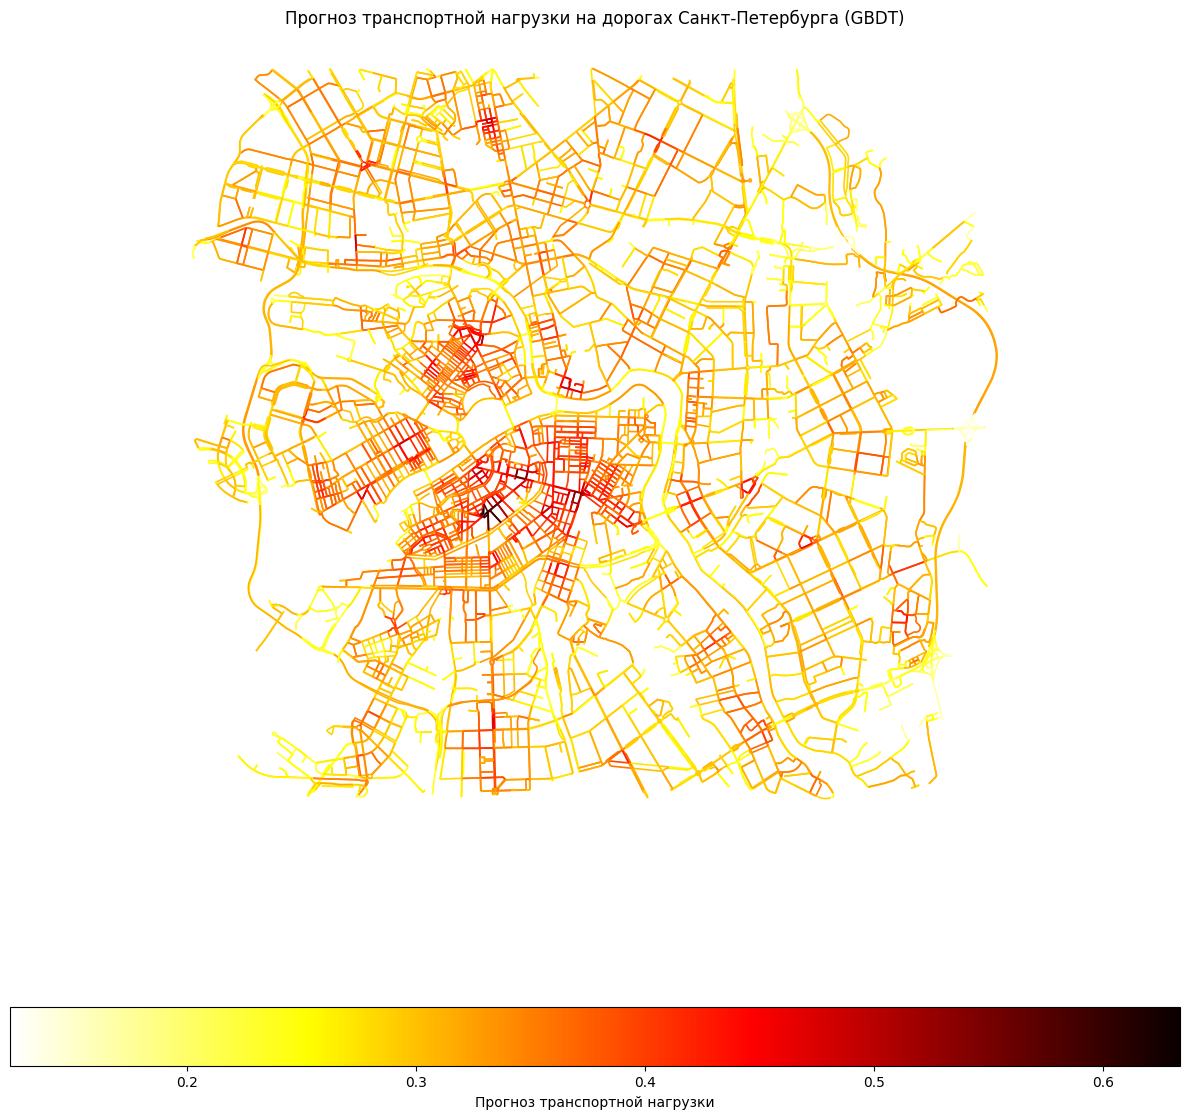

In [20]:
# Прогноз для всех дорог
roads["predicted_traffic_load"] = best_model.predict(X)

# Возвращаем геометрию в WGS84 для удобной визуализации
roads_wgs = gpd.GeoDataFrame(roads, geometry="geometry", crs=edges_m.crs).to_crs(4326)

# Строим карту
fig, ax = plt.subplots(figsize=(12, 12))

roads_wgs.plot(
    ax=ax,
    column="predicted_traffic_load",
    linewidth=1.2,
    legend=True,
    cmap="hot_r",  # красный = высокая нагрузка
    legend_kwds={"label": "Прогноз транспортной нагрузки", "orientation": "horizontal"}
)

ax.set_title("Прогноз транспортной нагрузки на дорогах Санкт-Петербурга (GBDT)")
ax.set_axis_off()

plt.tight_layout()
plt.show()